<a href="https://colab.research.google.com/github/Sonia1895/PROCESAMIENTO_CLASIFICACION_DATOS/blob/main/Tarea_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de datos a partir de los guiones de la serie Friends, utilizando exclusivamente el primer episodio de cada temporada



#**Obtención del texto**

In [ ]:
# Instalamos las librerías necesarias para el scraping web
!pip install requests beautifulsoup4

In [ ]:
import requests
from bs4 import BeautifulSoup

def extraer_guion(url):
    """
    Descarga y limpia el guion de una URL dada.
    Devuelve una lista de lineas de texto (strings).
    """
    response = requests.get(url)
    response.encoding = 'utf-8'
    soup = BeautifulSoup(response.text, 'html.parser')

    # Eliminar elementos que no forman parte del guion
    for tag in soup.select('nav, footer, .footer, script, style'):
        tag.decompose()

    # Extraer todo el texto separado por saltos de linea
    contenido = soup.get_text(separator='\n', strip=True)

    # Separar por saltos de linea y eliminar lineas vacias
    lineas = contenido.split('\n')
    texto_limpio = list(filter(None, lineas))

    # Eliminar lineas que solo contienen guiones (separadores)
    texto_limpio = [
        linea for linea in texto_limpio
        if linea.strip() != '--------------------------------------------------------------------------------'
    ]

    return texto_limpio

In [ ]:
# URLs de los primeros episodios de cada temporada
urls = {
    "episodio_1_temporada_1":  "https://www.friendspeich.com/guiones/101.php",
    "episodio_1_temporada_2":  "https://www.friendspeich.com/guiones/201.php",
    "episodio_1_temporada_3":  "https://www.friendspeich.com/guiones/301.php",
    "episodio_1_temporada_4":  "https://www.friendspeich.com/guiones/401.php",
    "episodio_1_temporada_5":  "https://www.friendspeich.com/guiones/501.php",
    "episodio_1_temporada_6":  "https://www.friendspeich.com/guiones/601.php",
    "episodio_1_temporada_7":  "https://www.friendspeich.com/guiones/701.php",
    "episodio_1_temporada_8":  "https://www.friendspeich.com/guiones/801.php",
    "episodio_1_temporada_9":  "https://www.friendspeich.com/guiones/901.php",
    "episodio_1_temporada_10": "https://www.friendspeich.com/guiones/1001.php"
}

# Descargar todos los guiones y guardarlos en un diccionario
guiones = {}
for nombre, url in urls.items():
    guiones[nombre] = extraer_guion(url)
    print(f"{nombre} extraido — {len(guiones[nombre])} lineas")

episodio_1_temporada_1 extraido — 289 lineas
episodio_1_temporada_2 extraido — 248 lineas
episodio_1_temporada_3 extraido — 268 lineas
episodio_1_temporada_4 extraido — 272 lineas
episodio_1_temporada_5 extraido — 310 lineas
episodio_1_temporada_6 extraido — 318 lineas
episodio_1_temporada_7 extraido — 332 lineas
episodio_1_temporada_8 extraido — 442 lineas
episodio_1_temporada_9 extraido — 328 lineas
episodio_1_temporada_10 extraido — 415 lineas


In [ ]:
# Obtener las primeras 10 lineas que cada episodio

temporadas = {
    '1', '2', '3', '4', '5', '6',
    '7', '8', '9', '10'
}

for temporada in range(1, 11):
    clave = f"episodio_1_temporada_{temporada}"

    print(f"\nPrimeras 10 líneas del episodio 1 de la temporada {temporada}:")

    for linea in guiones[clave][:10]:
        print(" -", linea)


Primeras 10 líneas del episodio 1 de la temporada 1:
 - Friends Peich - Guiones - En el que Monica tiene una compañera
 - Guiones
 - En el que Monica tiene una compañera (El piloto)
 - Escrito por Marta Kauffman y David Crane.
 - Transcrito por Elena Pérez.
 - [Escena: Central Perk. Monica, Phoebe, Joey y Chandler]
 - MONICA: No hay nada que contar! Solo es un compañero más!
 - JOEY: Confiésalo... vas a salir con ese tío! Algo raro tiene que tener!
 - CHANDLER: Qué pasa, tiene joroba? Joroba y bisoñe?
 - PHOEBE: Espera, suele mascar tiza?

Primeras 10 líneas del episodio 1 de la temporada 2:
 - Friends Peich - Guiones - El de la nueva novia de Ross
 - Guiones
 - El de la nueva novia de Ross
 - Escrito por Jeff Astroff y Mike Sikowitz .
 - Transcrito por Elena Pérez.
 - [Escena: Central Perk. Phoebe nos explica lo que había pasado en el último episodio. Mientras habla vemos un montaje con las escenas de Ross y Rachel]
 - PHOEBE: Vale, esto es lo que había pasado hasta el momento. Ross 

#**Procesamiento de datos**

In [ ]:
# Instalamos las librerias de NLP en español
!pip install spacy
# Descargamos el modelo de español de spaCy
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 20.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import unicodedata

#Funcion para quitar acentos
def quitar_acentos(texto):
    """
    Convierte letras con acento a su equivalente sin acento.
    Ejemplo: 'también' -> 'tambien'
    """
    # Normaliza a la forma NFD (separa letra base del acento)
    texto_normalizado = unicodedata.normalize('NFD', texto)
    # Se queda solo con los caracteres que NO son marcas diacriticas
    return ''.join(c for c in texto_normalizado if unicodedata.category(c) != 'Mn')

In [ ]:
import re

def limpiar_texto(texto):
    """
    Convierte el texto a minusculas, quita signos de puntuacion y quita acentos.
    """
    texto = texto.lower()
    # Eliminamos todo lo que no sea letra o espacio
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto)
    texto = quitar_acentos(texto)
    return texto

In [ ]:
import spacy

# Cargamos el modelo de español de spaCy
nlp = spacy.load('es_core_news_md')


# Lista de nombres de personajes principales de Friends
# Estos nombres NO se lematizaran, se conservaran como estan
personaje = {
    'MONICA', 'RACHEL', 'PHOEBE', 'JOEY', 'CHANDLER', 'ROSS',
    'monica', 'rachel', 'phoebe', 'joey', 'chandler', 'ross'
}


def lematizar_texto(texto):
    """
    Lematiza el texto en español usando spaCy.
    Los nombres de personajes se conservan sin cambios.
    Tambien se eliminan stopwords y tokens muy cortos (<= 1 caracter).
    """
    doc = nlp(texto)
    tokens_lematizados = []

    for token in doc:
        # Si el token es un personaje, lo conservamos tal cual
        if token.text.upper() in personaje:
            tokens_lematizados.append(token.text)
        # Descartamos stopwords, signos de puntuacion y tokens de 1 caracter
        elif not token.is_stop and not token.is_punct and len(token.text) > 1:
            tokens_lematizados.append(token.lemma_)

    return tokens_lematizados

In [ ]:
def extraer_dialogos(lista_lineas):
    """
    Recorre las lineas del guion y separa:
    - Las acotaciones (lineas entre corchetes, ej: [Escena: Central Perk])
    - Los dialogos con su personaje (ej: MONICA: Hola a todos)

    Devuelve una lista de diccionarios con:
        {'personaje': 'MONICA', 'dialogo': 'Hola a todos'}
    """
    dialogos = []

    for linea in lista_lineas:
        linea = linea.strip()

        # Ignoramos acotaciones de escena (entre corchetes)
        if linea.startswith('['):
            continue

        # Buscamos el patron NOMBRE: dialogo
        # El nombre del personaje esta en mayusculas antes de los dos puntos
        match = re.match(r'^([A-Za-z][A-Za-z\s\.]+):\s*(.+)$', linea)
        if match:
            personaje = match.group(1).strip().upper()
            dialogo   = match.group(2).strip()
            dialogos.append({'personaje': personaje, 'dialogo': dialogo})

    return dialogos


In [ ]:
dialogos_ep1 = extraer_dialogos(guiones["episodio_1_temporada_1"])
print(f"Total de dialogos en T1E1: {len(dialogos_ep1)}")
print("\nEjemplo de los primeros 3 dialogos:")
for d in dialogos_ep1[:3]:
    print(f"  [{d['personaje']}]: {d['dialogo']}")

Total de dialogos en T1E1: 239

Ejemplo de los primeros 3 dialogos:
  [MONICA]: No hay nada que contar! Solo es un compañero más!
  [JOEY]: Confiésalo... vas a salir con ese tío! Algo raro tiene que tener!
  [CHANDLER]: Qué pasa, tiene joroba? Joroba y bisoñe?


In [ ]:
# Procesamos todos los episodios y construimos un DataFrame general
# con columnas: episodio, temporada, personaje, dialogo, tokens_lematizados

import pandas as pd

filas = []

for nombre_episodio, lineas in guiones.items():

    # Extraemos el numero de temporada del nombre del episodio
    temporada = int(nombre_episodio.split('_')[-1])

    # Obtenemos los dialogos del episodio
    dialogos = extraer_dialogos(lineas)

    for d in dialogos:
        # Limpiamos el texto del dialogo
        texto_limpio = limpiar_texto(d['dialogo'])

        # Lematizamos y eliminamos stopwords
        tokens = lematizar_texto(texto_limpio)

        filas.append({
            'episodio':           nombre_episodio,
            'temporada':          temporada,
            'personaje':          d['personaje'],
            'dialogo_original':   d['dialogo'],
            'dialogo_limpio':     texto_limpio,
            'tokens_lematizados': tokens,
            'texto_lematizado':   ' '.join(tokens)  # version en string para TF-IDF
        })

# Convertimos a DataFrame de pandas
df = pd.DataFrame(filas)

print(f"Total de filas en el DataFrame: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()

Total de filas en el DataFrame: 2616
Columnas: ['episodio', 'temporada', 'personaje', 'dialogo_original', 'dialogo_limpio', 'tokens_lematizados', 'texto_lematizado']


,episodio,temporada,personaje,dialogo_original,dialogo_limpio,tokens_lematizados,texto_lematizado
0,episodio_1_temporada_1,1,MONICA,No hay nada que contar! Solo es un compañero más!,no hay nada que contar solo es un companero mas,"[contar, companero]",contar companero
1,episodio_1_temporada_1,1,JOEY,Confiésalo... vas a salir con ese tío! Algo ra...,confiesalo vas a salir con ese tio algo raro t...,"[confiesalo, ir, salir, tio, raro]",confiesalo ir salir tio raro
2,episodio_1_temporada_1,1,CHANDLER,"Qué pasa, tiene joroba? Joroba y bisoñe?",que pasa tiene joroba joroba y bisone,"[pasar, joroba, joroba, bisone]",pasar joroba joroba bisone
3,episodio_1_temporada_1,1,PHOEBE,"Espera, suele mascar tiza?",espera suele mascar tiza,"[esperar, soler, mascar, tiza]",esperar soler mascar tiza
4,episodio_1_temporada_1,1,PHOEBE,No me gustaría que pasase por lo que pase yo c...,no me gustaria que pasase por lo que pase yo c...,"[gustariar, pasar, pasar, carl, oh]",gustariar pasar pasar carl oh


In [ ]:
# Resumen: cuantos dialogos tiene cada personaje en total
print("Dialogos por personaje (todos los episodios):")
print(df['personaje'].value_counts().head(15))

Dialogos por personaje (todos los episodios):
personaje
RACHEL         473
ROSS           472
MONICA         400
CHANDLER       357
JOEY           331
PHOEBE         308
SRA. PHOEBE     20
MONA            17
JACK            17
PAUL            14
MIKE            14
JANICE          13
MR. GELLER      12
CHARLIE         11
PRECIOSA        11
Name: count, dtype: int64


In [ ]:
# Resumen: cuantos dialogos tiene cada episodio
print("Dialogos por episodio:")
print(df['episodio'].value_counts().head(15))

Dialogos por episodio:
episodio
episodio_1_temporada_10    351
episodio_1_temporada_9     292
episodio_1_temporada_8     274
episodio_1_temporada_7     263
episodio_1_temporada_5     262
episodio_1_temporada_6     257
episodio_1_temporada_1     239
episodio_1_temporada_3     238
episodio_1_temporada_4     224
episodio_1_temporada_2     216
Name: count, dtype: int64


In [ ]:
# Nos quedamos solo con los 6 personajes principales para los analisis
personaje_filtro = ['MONICA', 'RACHEL', 'PHOEBE', 'JOEY', 'CHANDLER', 'ROSS']

df_principales = df[df['personaje'].isin(personaje_filtro)].copy()

print(f"Filas con personajes principales: {len(df_principales)}")
print(df_principales['personaje'].value_counts())

Filas con personajes principales: 2341
personaje
RACHEL      473
ROSS        472
MONICA      400
CHANDLER    357
JOEY        331
PHOEBE      308
Name: count, dtype: int64


#**Estadísticas comparativas entre episodios**


In [ ]:
from collections import Counter
from itertools import chain
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Contamos la cantidad de tokens lematizados por episodio
# Usamos df_principales para quedarnos solo con los 6 personajes principales
palabras_por_episodio = (
    df_principales
    .groupby('temporada')['tokens_lematizados']
    .apply(lambda listas: sum(len(tokens) for tokens in listas))
    .reset_index()
)
palabras_por_episodio.columns = ['temporada', 'total_palabras']

print("Cantidad de palabras (lematizadas, sin stopwords) por episodio:")
print(palabras_por_episodio.to_string(index=False))

Cantidad de palabras (lematizadas, sin stopwords) por episodio:
 temporada  total_palabras
         1             983
         2             943
         3             830
         4             906
         5             845
         6             960
         7            1014
         8             598
         9             881
        10            1154


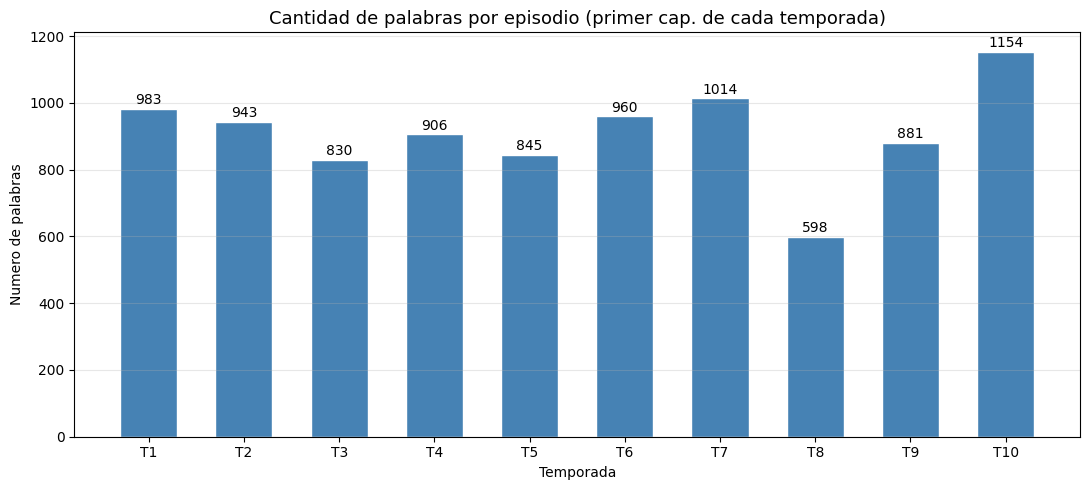

In [ ]:
# Grafico de barras: palabras por episodio
fig, ax = plt.subplots(figsize=(11, 5))

barras = ax.bar(
    palabras_por_episodio['temporada'],
    palabras_por_episodio['total_palabras'],
    color='steelblue',
    edgecolor='white',
    width=0.6
)

# Mostramos el valor encima de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 5,
        str(int(altura)),
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Cantidad de palabras por episodio (primer cap. de cada temporada)', fontsize=13)
ax.set_xlabel('Temporada')
ax.set_ylabel('Numero de palabras')
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f'T{i}' for i in range(1, 11)])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('palabras_por_episodio.png', dpi=150)
plt.show()

In [ ]:
# Contamos el numero de dialogos de cada personaje en cada temporada
dialogos_por_personaje = (
    df_principales
    .groupby(['temporada', 'personaje'])
    .size()
    .reset_index()
)
dialogos_por_personaje.columns = ['temporada', 'personaje', 'num_dialogos']

# Para cada temporada, encontramos el personaje con mas dialogos
personaje_lider = (
    dialogos_por_personaje
    .loc[dialogos_por_personaje.groupby('temporada')['num_dialogos'].idxmax()]
    .reset_index(drop=True)
)

print("Personaje con mas dialogos en cada episodio:")
print(personaje_lider.to_string(index=False))

Personaje con mas dialogos en cada episodio:
 temporada personaje  num_dialogos
         1    MONICA            63
         2    RACHEL            48
         3      ROSS            47
         4      ROSS            43
         5      ROSS            54
         6  CHANDLER            52
         7    RACHEL            60
         8    MONICA            48
         9    RACHEL            61
        10    RACHEL            67


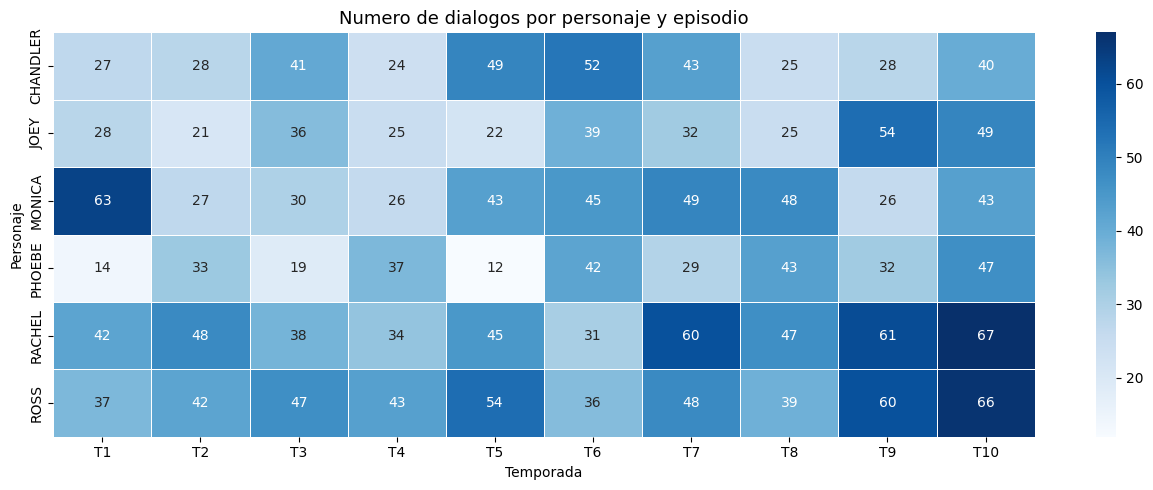

In [ ]:
#  Tabla de dialogos completa (todos los personajes por temporada)
# Convertimos a tabla pivote para verlo como heatmap
pivot_dialogos = dialogos_por_personaje.pivot(
    index='personaje',
    columns='temporada',
    values='num_dialogos'
).fillna(0).astype(int)

pivot_dialogos.columns = [f'T{c}' for c in pivot_dialogos.columns]

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    pivot_dialogos,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    ax=ax
)

ax.set_title('Numero de dialogos por personaje y episodio', fontsize=13)
ax.set_xlabel('Temporada')
ax.set_ylabel('Personaje')

plt.tight_layout()
plt.show()

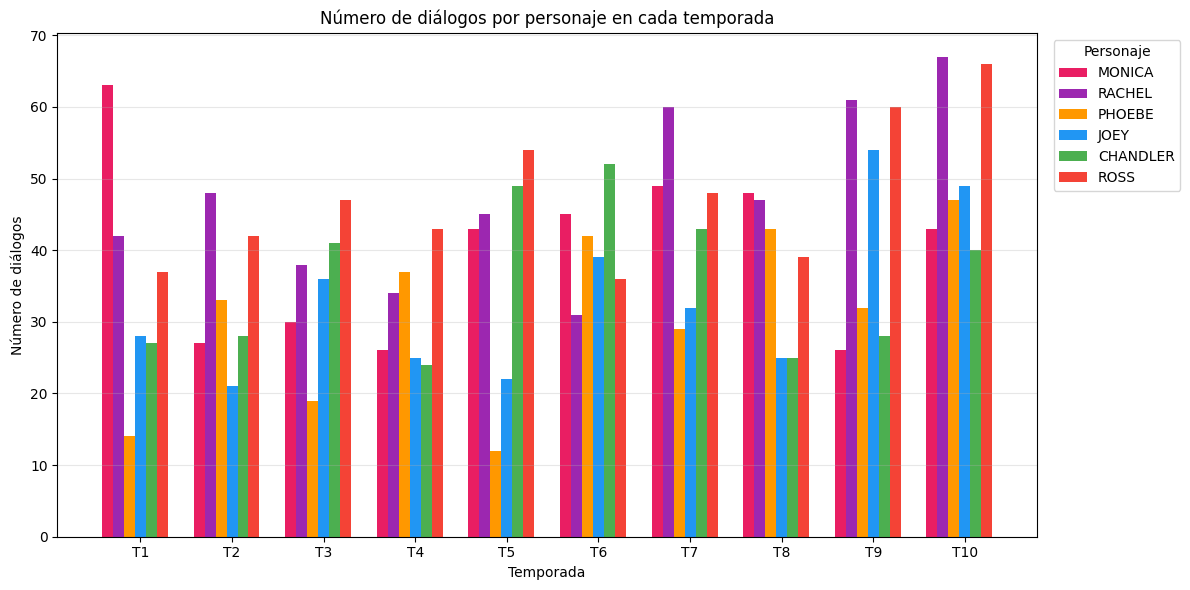

In [ ]:
# Lineas de participacion de cada personaje a lo largo de las temporadas
fig, ax = plt.subplots(figsize=(12, 6))

# Colores fijos para cada personaje

colores_personajes = {
    'MONICA':   '#E91E63',
    'RACHEL':   '#9C27B0',
    'PHOEBE':   '#FF9800',
    'JOEY':     '#2196F3',
    'CHANDLER': '#4CAF50',
    'ROSS':     '#F44336'
}

personajes = personaje_filtro
temporadas = sorted(dialogos_por_personaje['temporada'].unique())

x = np.arange(len(temporadas))  # posiciones en X
ancho = 0.12  # ancho de cada barra

for i, personaje in enumerate(personajes):
    datos = dialogos_por_personaje[
        dialogos_por_personaje['personaje'] == personaje
    ].sort_values('temporada')

    ax.bar(
        x + i * ancho,
        datos['num_dialogos'],
        width=ancho,
        label=personaje,
        color=colores_personajes.get(personaje, 'gray')
    )

ax.set_title('Número de diálogos por personaje en cada temporada')
ax.set_xlabel('Temporada')
ax.set_ylabel('Número de diálogos')

ax.set_xticks(x + ancho * (len(personajes) / 2))
ax.set_xticklabels([f'T{i}' for i in temporadas])

ax.legend(title='Personaje', bbox_to_anchor=(1.01, 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def obtener_ngramas(lista_de_listas_tokens, n, top_n=15):
    """
    Recibe una lista de listas de tokens y calcula los n-gramas mas frecuentes.

    Parametros:
        lista_de_listas_tokens: cada elemento es la lista de tokens de un dialogo
        n: tamano del n-grama (2 = bigrama, 3 = trigrama)
        top_n: cuantos de los mas frecuentes devolver

    Devuelve un Counter con los n-gramas y su frecuencia.
    """
    # Aplanamos todas las listas de tokens en una sola lista de palabras
    todas_las_palabras = list(chain.from_iterable(lista_de_listas_tokens))

    # Generamos los n-gramas como tuplas
    # zip(*[lista[i:] for i in range(n)]) desplaza la lista n veces y los combina en tuplas
    ngramas = list(zip(*[todas_las_palabras[i:] for i in range(n)]))

    # Contamos frecuencias y devolvemos los top_n
    conteo = Counter(ngramas)
    return conteo.most_common(top_n)

# Obtenemos bigramas y trigramas de todos los episodios combinados
todos_los_tokens = df_principales['tokens_lematizados'].tolist()

bigramas_globales  = obtener_ngramas(todos_los_tokens, n=2, top_n=15)
trigramas_globales = obtener_ngramas(todos_los_tokens, n=3, top_n=15)

print("Top 15 bigramas mas frecuentes (todos los episodios):")
for ngrama, freq in bigramas_globales:
    print(f"  {' '.join(ngrama):30s} -> {freq} veces")

print("\nTop 15 trigramas mas frecuentes (todos los episodios):")
for ngrama, freq in trigramas_globales:
    print(f"  {' '.join(ngrama):40s} -> {freq} veces")

Top 15 bigramas mas frecuentes (todos los episodios):
  hola hola                      -> 28 veces
  oh dios                        -> 11 veces
  proponer matrimonio            -> 11 veces
  oh hola                        -> 9 veces
  abrir puerta                   -> 9 veces
  sentir sentir                  -> 7 veces
  cerrar puerta                  -> 7 veces
  tener razon                    -> 6 veces
  pensar oh                      -> 6 veces
  ross rachel                    -> 6 veces
  ross hola                      -> 5 veces
  ross ross                      -> 5 veces
  ah oir                         -> 5 veces
  ver ross                       -> 5 veces
  hablar momento                 -> 5 veces

Top 15 trigramas mas frecuentes (todos los episodios):
  joey proponer matrimonio                 -> 4 veces
  hola hola hola                           -> 3 veces
  hiciste hacer hiciste                    -> 3 veces
  ross hola hola                           -> 2 veces
  zapato za

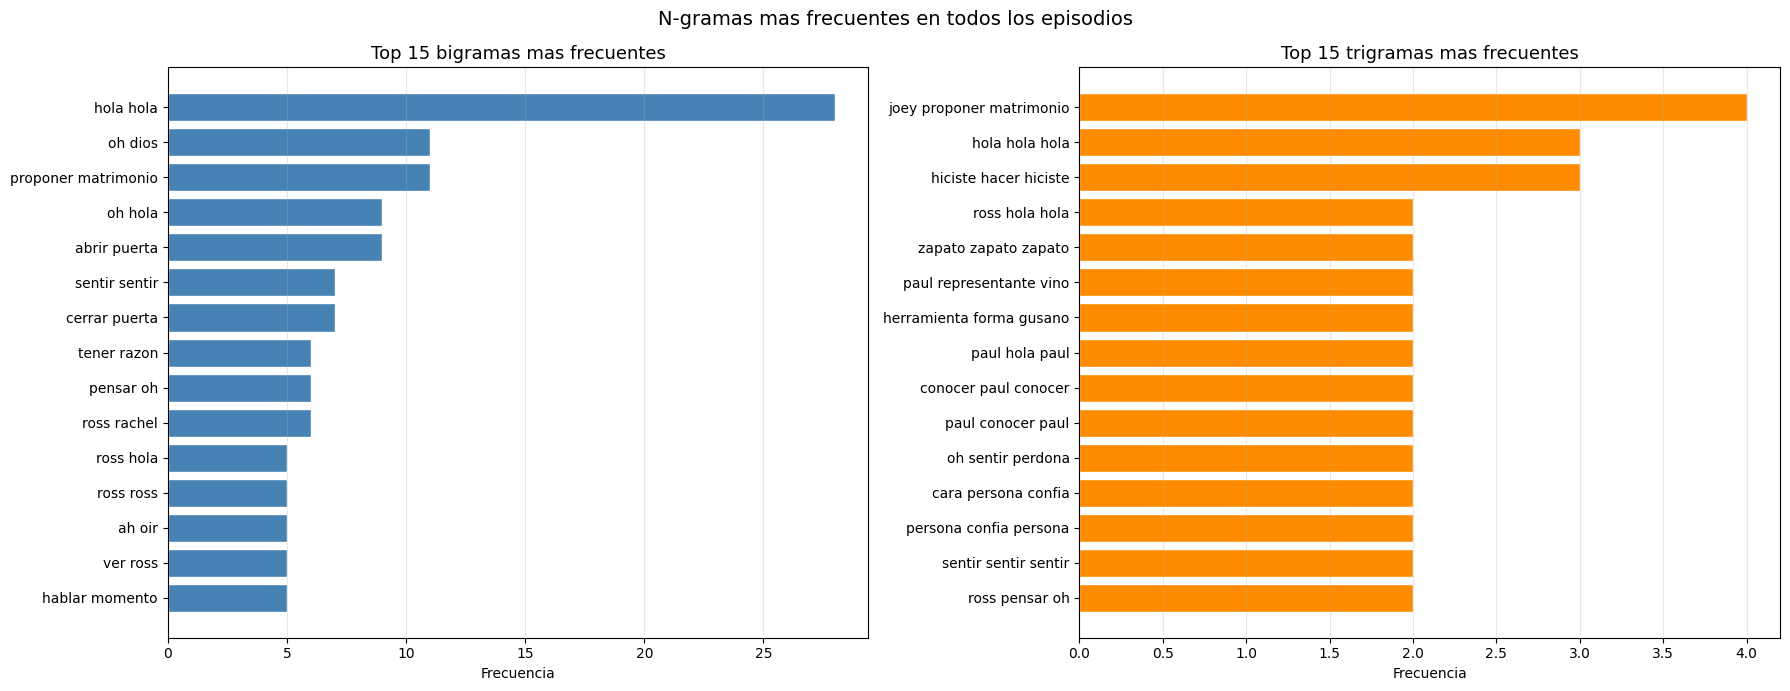

In [ ]:
# Graficamos bigramas y trigramas globales
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Bigramas ---
etiquetas_bi = [' '.join(ng) for ng, _ in bigramas_globales]
frecuencias_bi = [f for _, f in bigramas_globales]

axes[0].barh(etiquetas_bi[::-1], frecuencias_bi[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 bigramas mas frecuentes', fontsize=13)
axes[0].set_xlabel('Frecuencia')
axes[0].grid(axis='x', alpha=0.3)

# --- Trigramas ---
etiquetas_tri = [' '.join(ng) for ng, _ in trigramas_globales]
frecuencias_tri = [f for _, f in trigramas_globales]

axes[1].barh(etiquetas_tri[::-1], frecuencias_tri[::-1], color='darkorange', edgecolor='white')
axes[1].set_title('Top 15 trigramas mas frecuentes', fontsize=13)
axes[1].set_xlabel('Frecuencia')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('N-gramas mas frecuentes en todos los episodios', fontsize=14)
plt.tight_layout()
plt.savefig('ngramas_globales.png', dpi=150)
plt.show()

In [ ]:
# N-gramas por episodio: bigramas en cada temporada
# Mostramos los 5 bigramas mas frecuentes de cada temporada
print("Top 5 bigramas por temporada:\n")

for temporada in range(1, 11):
    # Filtramos los tokens de esta temporada
    tokens_temporada = (
        df_principales[df_principales['temporada'] == temporada]['tokens_lematizados']
        .tolist()
    )
    top_bi = obtener_ngramas(tokens_temporada, n=2, top_n=5)
    frases = ', '.join([' '.join(ng) for ng, _ in top_bi])
    print(f"  T{temporada}: {frases}")

Top 5 bigramas por temporada:

  T1: zapato zapato, coger cucurucho, conocer paul, paul representante, representante vino
  T2: demi moore, ross enamorado, ross julie, julie ross, sentir sentir
  T3: princesa leiar, lugar feliz, monica hola, hola monica, hola hola
  T4: voz off, madre natural, cavar hoyo, discovery channel, chandler monica
  T5: hola hola, ross nombre, ross tomar, ah valer, ross emily
  T6: hola hola, seguir casado, correr correr, espera espera, oh dios
  T7: oh dios, valer monica, hola hola, ross rachel, robar protagonismo
  T8: james brolin, monica embarazado, ed begley, begley hijo, mesa oh
  T9: proponer matrimonio, necesitar hablar, anillo compromiso, hola hola, joey proponer
  T10: hola hola, rachel joey, joey rachel, ver besar, hablar joey


In [ ]:
# Calculamos las 10 palabras mas frecuentes de cada temporada
# Guardamos los resultados en un diccionario para graficar

palabras_frecuentes_por_temporada = {}

for temporada in range(1, 11):
    # Obtenemos todos los tokens de esta temporada
    tokens_temporada = (
        df_principales[df_principales['temporada'] == temporada]['tokens_lematizados']
        .tolist()
    )
    # Aplanamos la lista de listas
    todas = list(chain.from_iterable(tokens_temporada))

    # Filtramos nombres de personajes para que no dominen el ranking
    # (ya que son mencionados muy frecuentemente)
    nombres = {p.lower() for p in personaje_filtro}
    todas_sin_nombres = [p for p in todas if p.lower() not in nombres]

    # Contamos y guardamos top 10
    conteo = Counter(todas_sin_nombres)
    palabras_frecuentes_por_temporada[temporada] = conteo.most_common(10)

# Mostramos el resumen en texto
print("Top 10 palabras mas frecuentes por temporada (excluye nombres de personajes):\n")
for temporada, top in palabras_frecuentes_por_temporada.items():
    palabras = ', '.join([f"{p}({f})" for p, f in top])
    print(f"  T{temporada}: {palabras}")

Top 10 palabras mas frecuentes por temporada (excluye nombres de personajes):

  T1: paul(17), pasar(15), oh(14), ver(12), haber(11), sentir(10), ir(9), querer(9), cita(8), hola(8)
  T2: julie(16), valer(15), oir(14), oh(13), tio(11), hola(10), sentir(10), ver(10), hablar(9), ir(9)
  T3: hola(14), decir(11), pasar(10), valer(9), janice(9), feliz(7), serio(7), oh(7), hablar(6), richard(6)
  T4: valer(12), madre(11), volver(11), oh(10), hablar(10), haber(10), cosa(9), carta(9), hoyo(9), levantar(7)
  T5: oh(21), emily(19), hola(15), oir(13), ver(12), valer(11), esperar(11), significar(11), pasar(9), quedar(8)
  T6: querer(15), hola(15), valer(14), decir(12), oh(10), casado(9), oir(9), casar(8), pensar(8), estar(8)
  T7: oh(30), noche(20), valer(18), querer(15), serio(12), ver(11), boda(11), pasar(10), gracia(10), poder(10)
  T8: oh(21), valer(17), embarazado(9), ver(9), bailar(8), hablar(7), mona(7), tener(6), venir(6), pensar(6)
  T9: matrimonio(21), anillo(20), hola(19), hablar(15), eh

/tmp/ipykernel_8521/683627006.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(palabras_g, rotation=45, ha='right')


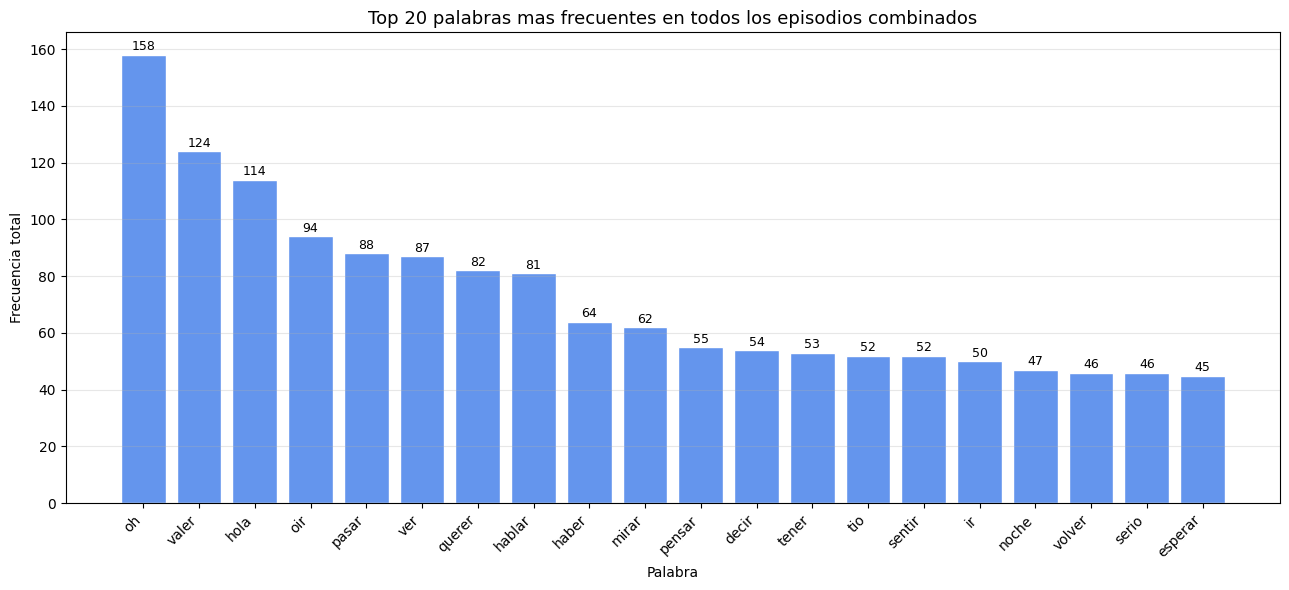

In [ ]:
# Comparamos las palabras mas frecuentes en TODOS los episodios usando una nube de palabras ponderada por frecuencia total

# Aplanamos todos los tokens de todos los episodios
todos_tokens_planos = list(chain.from_iterable(df_principales['tokens_lematizados'].tolist()))

# Excluimos nombres de personajes
nombres = {p.lower() for p in personaje_filtro}
tokens_sin_nombres = [t for t in todos_tokens_planos if t.lower() not in nombres]

# Top 20 palabras globales
top20_global = Counter(tokens_sin_nombres).most_common(20)

palabras_g  = [p for p, _ in top20_global]
frecuencias_g = [f for _, f in top20_global]

fig, ax = plt.subplots(figsize=(13, 6))

barras = ax.bar(
    palabras_g, frecuencias_g,
    color='cornflowerblue', edgecolor='white'
)

# Valor encima de cada barra
for barra in barras:
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        str(int(barra.get_height())),
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Top 20 palabras mas frecuentes en todos los episodios combinados', fontsize=13)
ax.set_xlabel('Palabra')
ax.set_ylabel('Frecuencia total')
ax.set_xticklabels(palabras_g, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import re

personajes = personaje_filtro

# inicializamos lista de resultados
resultados = []

for episodio, grupo in df.groupby("episodio"):
    conteo = {p: 0 for p in personajes}

    for dialogo in grupo["dialogo_original"]:
        texto = dialogo.upper()

        for p in personajes:
            pattern = r"\b" + re.escape(p) + r"\b"
            conteo[p] += len(re.findall(pattern, texto))

    conteo["episodio"] = episodio
    resultados.append(conteo)

df_menciones_ep = pd.DataFrame(resultados)

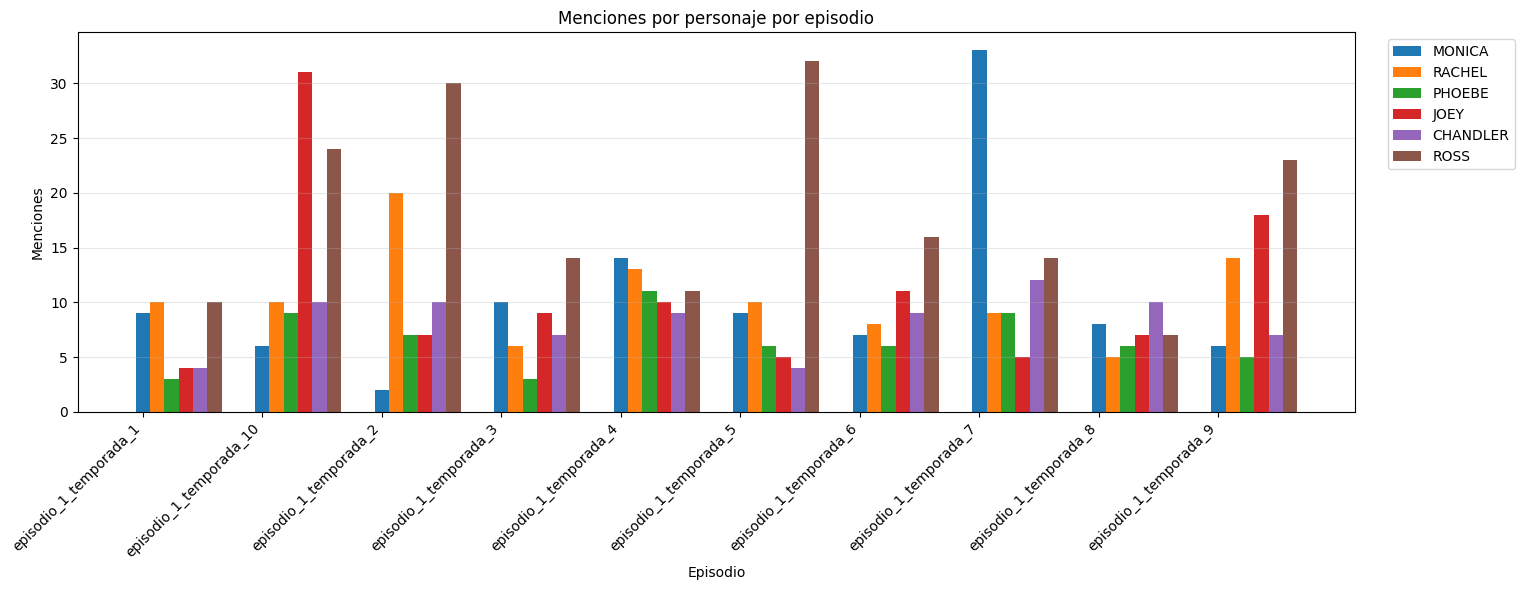

In [ ]:

df_plot = df_menciones_ep.copy()

fig, ax = plt.subplots(figsize=(14,6))

episodios = df_plot["episodio"]
personajes = personaje_filtro

x = np.arange(len(episodios))
ancho = 0.12

for i, personaje in enumerate(personajes):
    ax.bar(
        x + i * ancho,
        df_plot[personaje],
        width=ancho,
        label=personaje
    )

ax.set_xticks(x)
ax.set_xticklabels(episodios, rotation=45, ha='right')

ax.set_title("Menciones por personaje por episodio")
ax.set_xlabel("Episodio")
ax.set_ylabel("Menciones")

ax.legend(bbox_to_anchor=(1.02, 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

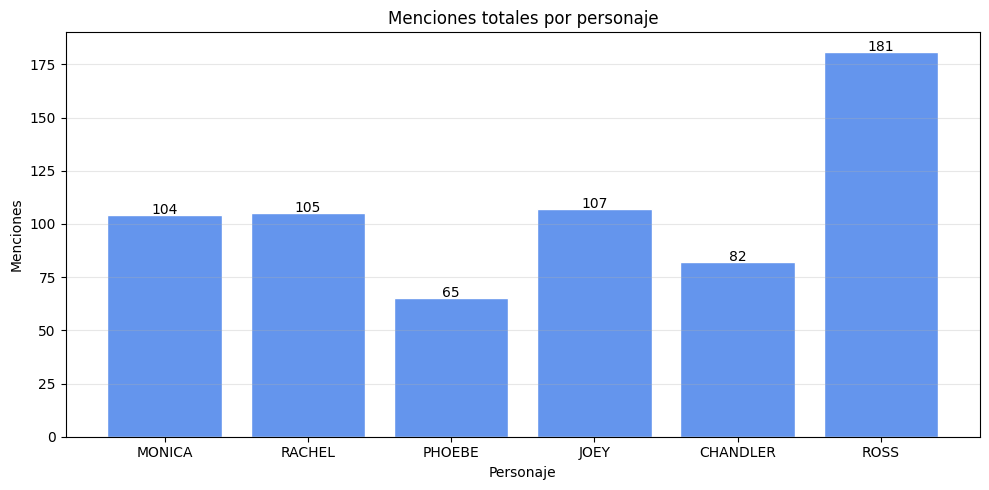

In [ ]:
import matplotlib.pyplot as plt

totales = df_plot[personaje_filtro].sum()

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(
    totales.index,
    totales.values,
    color='cornflowerblue',
    edgecolor='white'
)

# valores encima
for i, v in enumerate(totales.values):
    ax.text(i, v + 0.5, str(int(v)), ha='center')

ax.set_title("Menciones totales por personaje")
ax.set_xlabel("Personaje")
ax.set_ylabel("Menciones")

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#**Análisis de Correlación**

Convertimos cada episodio en un vector de frecuencia de palabras (TF-IDF)
y luego calculamos la correlacion de Pearson entre episodios.

¿Qué tan parecidos son entre sí los episodios en cuanto a las palabras que usan?

**Interpretacion:** Un valor cercano a 1 indica que dos episodios usan vocabulario
muy similar; cercano a 0 indica poca relacion en el vocabulario.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupamos todos los dialogos lematizados de cada episodio en un solo texto
# Cada episodio queda representado por un string con todas sus palabras
textos_por_episodio = (
    df_principales
    .groupby('episodio')['texto_lematizado']
    .apply(lambda textos: ' '.join(textos))
)

# Etiquetas  para los graficos (T1, T2, ..., T10)
etiquetas = [f"T{i}" for i in range(1, 11)]

# Aplicamos TF-IDF para convertir cada episodio en un vector numerico
# TF-IDF pondera las palabras segun su importancia dentro y entre episodios
vectorizador = TfidfVectorizer()
matriz_tfidf = vectorizador.fit_transform(textos_por_episodio)

# Convertimos a DataFrame para calcular correlaciones facilmente
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    index=etiquetas
)

# Calculamos la matriz de correlacion de Pearson entre episodios
# Trasponemos porque queremos correlacion entre episodios (filas), no palabras
matriz_correlacion = df_tfidf.T.corr()

print("Matriz de correlacion entre episodios:")
print(matriz_correlacion.round(3))

Matriz de correlacion entre episodios:
        T1     T2     T3     T4     T5     T6     T7     T8     T9    T10
T1   1.000  0.235  0.186  0.131  0.177  0.187  0.192  0.231  0.145  0.167
T2   0.235  1.000  0.323  0.240  0.302  0.325  0.306  0.375  0.273  0.323
T3   0.186  0.323  1.000  0.202  0.227  0.247  0.220  0.247  0.196  0.230
T4   0.131  0.240  0.202  1.000  0.161  0.166  0.163  0.215  0.131  0.178
T5   0.177  0.302  0.227  0.161  1.000  0.200  0.224  0.290  0.188  0.215
T6   0.187  0.325  0.247  0.166  0.200  1.000  0.249  0.318  0.225  0.208
T7   0.192  0.306  0.220  0.163  0.224  0.249  1.000  0.296  0.192  0.238
T8   0.231  0.375  0.247  0.215  0.290  0.318  0.296  1.000  0.285  0.274
T9   0.145  0.273  0.196  0.131  0.188  0.225  0.192  0.285  1.000  0.167
T10  0.167  0.323  0.230  0.178  0.215  0.208  0.238  0.274  0.167  1.000


In [ ]:
df_tfidf

,0,1,2,3,4,5,6,7,8,9,...,2753,2754,2755,2756,2757,2758,2759,2760,2761,2762
T1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039280,...,0.136688,0.000000,0.000000,0.000000,0.00000,0.000000,0.087308,0.000000,0.000000,0.136688
T2,0.000000,0.022779,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016941,...,0.067375,0.016941,0.000000,0.000000,0.00000,0.000000,0.015062,0.000000,0.000000,0.176860
T3,0.025324,0.000000,0.025324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.074904,0.018835,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.025324,0.112356
T4,0.000000,0.000000,0.000000,0.000000,0.026572,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.046226,0.000000,0.000000,0.000000,0.00000,0.062515,0.000000,0.000000,0.000000,0.173347
T5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.082582,0.000000,0.000000,0.020765,0.02792,0.000000,0.000000,0.000000,0.000000,0.237424
T6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020334,...,0.070758,0.081335,0.000000,0.020334,0.00000,0.000000,0.000000,0.000000,0.000000,0.070758
T7,0.000000,0.000000,0.000000,0.028477,0.048416,0.028477,0.028477,0.028477,0.000000,0.000000,...,0.126341,0.000000,0.056954,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.136870
T8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.075632,0.000000,0.000000,0.000000,0.00000,0.000000,0.033816,0.000000,0.000000,0.160718
T9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035681,0.000000,...,0.026384,0.000000,0.000000,0.000000,0.00000,0.000000,0.047187,0.035681,0.000000,0.092344
T10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.042711,0.000000,0.000000,0.017184,0.00000,0.000000,0.000000,0.000000,0.000000,0.247724


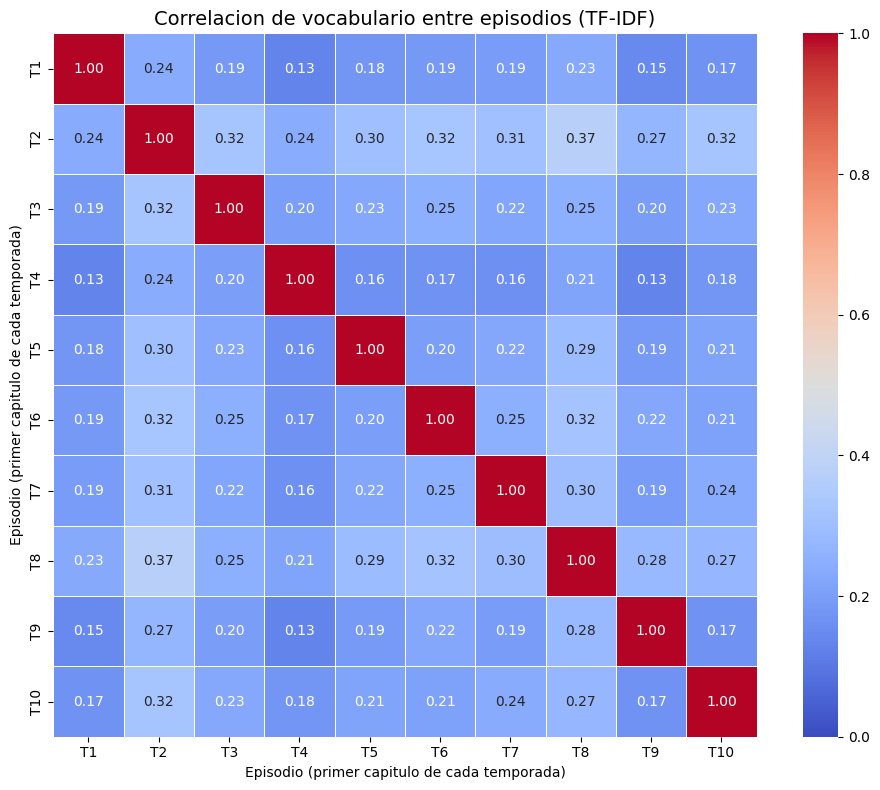

In [ ]:
# Visualizamos la matriz de correlacion como un heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,          # mostrar los valores numericos en cada celda
    fmt='.2f',           # formato de 2 decimales
    cmap='coolwarm',     # rojo = correlacion alta, azul = baja
    vmin=0, vmax=1,      # rango de la escala de color
    linewidths=0.5,
    square=True
)

plt.title('Correlacion de vocabulario entre episodios (TF-IDF)', fontsize=14)
plt.xlabel('Episodio (primer capitulo de cada temporada)')
plt.ylabel('Episodio (primer capitulo de cada temporada)')
plt.tight_layout()
plt.show()

In [ ]:
# Identificamos los pares de episodios con mayor y menor correlacion

correlacion_sin_diagonal = matriz_correlacion.copy()
np.fill_diagonal(correlacion_sin_diagonal.values, np.nan)

# Buscamos el par con maxima correlacion
max_corr = correlacion_sin_diagonal.stack().idxmax()
min_corr = correlacion_sin_diagonal.stack().idxmin()

print(f"Par con MAYOR correlacion: {max_corr[0]} y {max_corr[1]} "
      f"= {correlacion_sin_diagonal.loc[max_corr]:.3f}")
print(f"Par con MENOR correlacion: {min_corr[0]} y {min_corr[1]} "
      f"= {correlacion_sin_diagonal.loc[min_corr]:.3f}")

Par con MAYOR correlacion: T2 y T8 = 0.375
Par con MENOR correlacion: T4 y T9 = 0.131


# **Análisis de Distancia de Cosenos**

La **similitud de cosenos** mide el angulo entre dos vectores de texto.
- Valor cercano a **1** = textos muy similares en contenido
- Valor cercano a **0** = textos muy diferentes

La **distancia de cosenos** = 1 - similitud, por lo que:
- Valor cercano a **0** = textos muy similares
- Valor cercano a **1** = textos muy diferentes


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances

# Calculamos la similitud de cosenos entre todos los episodios
similitud_cosenos = cosine_similarity(matriz_tfidf)

# La distancia de cosenos es el complemento de la similitud
distancia_cosenos = 1 - similitud_cosenos

# Convertimos a DataFrames con etiquetas legibles
df_similitud = pd.DataFrame(similitud_cosenos, index=etiquetas, columns=etiquetas)
df_distancia = pd.DataFrame(distancia_cosenos, index=etiquetas, columns=etiquetas)

print("Similitud de cosenos entre episodios (1 = identicos, 0 = sin relacion):")
print(df_similitud.round(3))

Similitud de cosenos entre episodios (1 = identicos, 0 = sin relacion):
        T1     T2     T3     T4     T5     T6     T7     T8     T9    T10
T1   1.000  0.322  0.273  0.242  0.274  0.268  0.294  0.317  0.226  0.241
T2   0.322  1.000  0.390  0.329  0.377  0.386  0.386  0.439  0.336  0.378
T3   0.273  0.390  1.000  0.289  0.305  0.312  0.306  0.321  0.263  0.290
T4   0.242  0.329  0.289  1.000  0.262  0.251  0.271  0.305  0.215  0.253
T5   0.274  0.377  0.305  0.262  1.000  0.275  0.316  0.365  0.261  0.281
T6   0.268  0.386  0.312  0.251  0.275  1.000  0.325  0.379  0.284  0.266
T7   0.294  0.386  0.306  0.271  0.316  0.325  1.000  0.376  0.270  0.306
T8   0.317  0.439  0.321  0.305  0.365  0.379  0.376  1.000  0.346  0.332
T9   0.226  0.336  0.263  0.215  0.261  0.284  0.270  0.346  1.000  0.224
T10  0.241  0.378  0.290  0.253  0.281  0.266  0.306  0.332  0.224  1.000


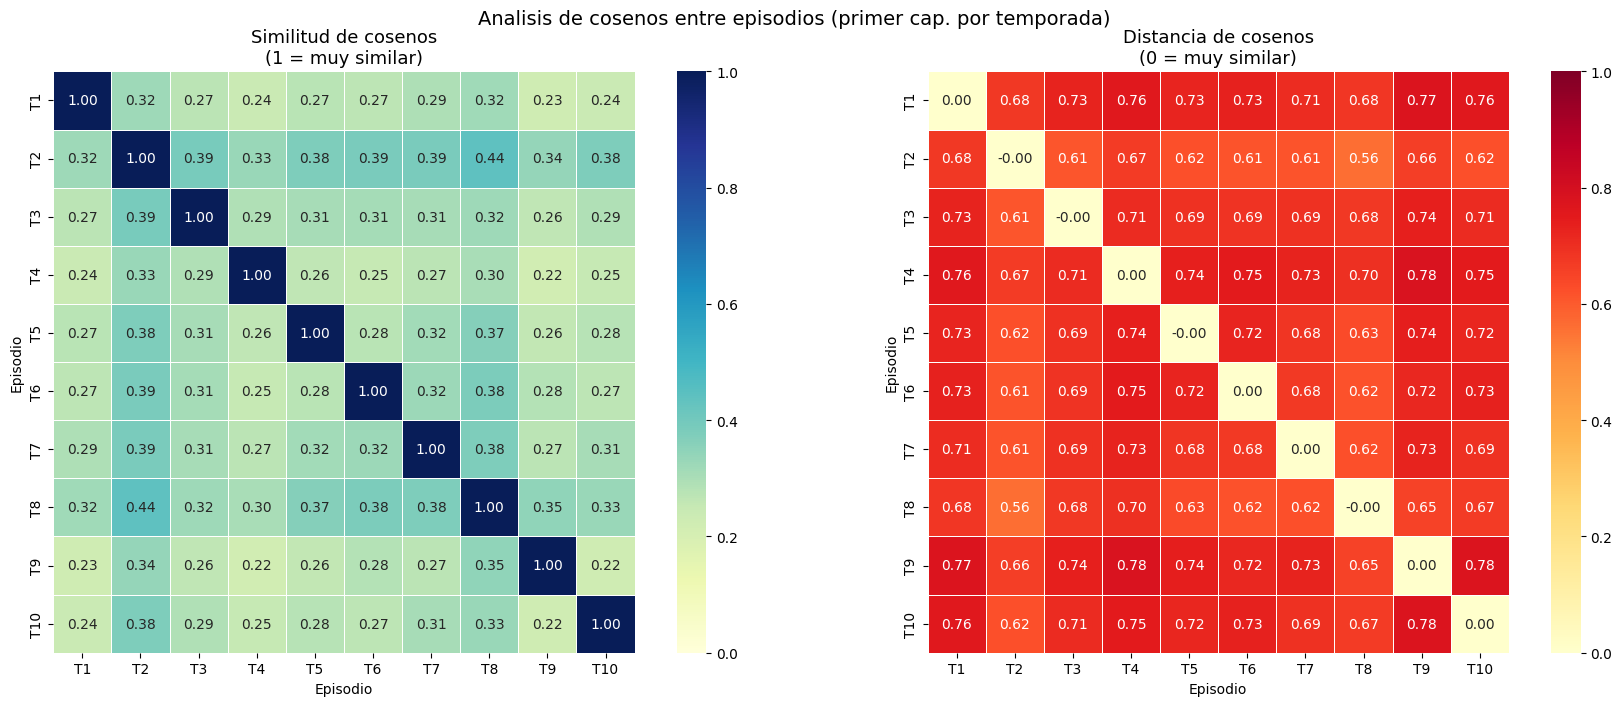

In [ ]:
# Graficamos la similitud de cosenos
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Grafico 1: Similitud ---
sns.heatmap(
    df_similitud,
    annot=True, fmt='.2f',
    cmap='YlGnBu',
    vmin=0, vmax=1,
    linewidths=0.5,
    square=True,
    ax=axes[0]
)
axes[0].set_title('Similitud de cosenos\n(1 = muy similar)', fontsize=13)
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Episodio')

# --- Grafico 2: Distancia ---
sns.heatmap(
    df_distancia,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5,
    square=True,
    ax=axes[1]
)
axes[1].set_title('Distancia de cosenos\n(0 = muy similar)', fontsize=13)
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Episodio')

plt.suptitle('Analisis de cosenos entre episodios (primer cap. por temporada)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Episodios mas cercanos y mas lejanos segun distancia de cosenos
dist_sin_diagonal = df_distancia.copy()
np.fill_diagonal(dist_sin_diagonal.values, np.nan)

par_mas_cercano = dist_sin_diagonal.stack().idxmin()
par_mas_lejano  = dist_sin_diagonal.stack().idxmax()

print(f"Episodios MAS SIMILARES (menor distancia): {par_mas_cercano[0]} y {par_mas_cercano[1]} "
      f"= distancia = {dist_sin_diagonal.loc[par_mas_cercano]:.3f}")
print(f"Episodios MAS DIFERENTES (mayor distancia): {par_mas_lejano[0]} y {par_mas_lejano[1]} "
      f"= distancia = {dist_sin_diagonal.loc[par_mas_lejano]:.3f}")

Episodios MAS SIMILARES (menor distancia): T2 y T8 = distancia = 0.561
Episodios MAS DIFERENTES (mayor distancia): T4 y T9 = distancia = 0.785


#**Análisis de Sentimientos por Personaje**

##Pysentimiento

In [ ]:
# Instalamos pysentimiento (analisis de sentimientos en español)
!pip install pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.1 MB/s eta 0:00:00


In [ ]:
from pysentimiento import create_analyzer

# Creamos el analizador de sentimientos para español

analizador = create_analyzer(task='sentiment', lang='es')



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Prueba -> 'POS' con probabilidades: {'NEG': 0.002474840497598052, 'NEU': 0.02927858754992485, 'POS': 0.9682465195655823}


In [ ]:
def analizar_sentimiento_dialogo(texto):
    """
    Analiza el sentimiento de un texto y devuelve:
    - etiqueta: 'POS', 'NEG' o 'NEU'
    - prob_pos: probabilidad de ser positivo (0 a 1)
    - prob_neg: probabilidad de ser negativo (0 a 1)
    - prob_neu: probabilidad de ser neutro (0 a 1)
    """
    try:
        resultado = analizador.predict(texto)
        return {
            'sentimiento': resultado.output,
            'prob_pos':    resultado.probas.get('POS', 0),
            'prob_neg':    resultado.probas.get('NEG', 0),
            'prob_neu':    resultado.probas.get('NEU', 0)
        }
    except Exception:
        # Si hay algun error (texto vacio, etc.) devolvemos neutro
        return {'sentimiento': 'NEU', 'prob_pos': 0, 'prob_neg': 0, 'prob_neu': 1}

# Aplicamos el analisis a cada dialogo del DataFrame de personajes principales

resultados_sentimiento = df_principales['dialogo_original'].apply(analizar_sentimiento_dialogo)

# Expandimos el diccionario resultado en columnas del DataFrame
df_sentimientos = pd.concat(
    [df_principales.reset_index(drop=True),
     pd.DataFrame(list(resultados_sentimiento))],
    axis=1
)

print(f"Total de dialogos analizados: {len(df_sentimientos)}")
df_sentimientos[['personaje', 'dialogo_original', 'sentimiento', 'prob_pos', 'prob_neg', 'prob_neu']].head()

Total de dialogos analizados: 2341


,personaje,dialogo_original,sentimiento,prob_pos,prob_neg,prob_neu
0,MONICA,No hay nada que contar! Solo es un compañero más!,POS,0.672805,0.015249,0.311946
1,JOEY,Confiésalo... vas a salir con ese tío! Algo ra...,NEG,0.010358,0.876378,0.113265
2,CHANDLER,"Qué pasa, tiene joroba? Joroba y bisoñe?",NEU,0.019427,0.177721,0.802852
3,PHOEBE,"Espera, suele mascar tiza?",NEU,0.049477,0.225904,0.724619
4,PHOEBE,No me gustaría que pasase por lo que pase yo c...,NEG,0.014703,0.837856,0.147441


In [ ]:
# Contamos cuantos dialogos positivos, negativos y neutros tiene cada personaje
conteo_sentimientos = (
    df_sentimientos
    .groupby(['personaje', 'sentimiento'])
    .size()
    .unstack(fill_value=0)  # cada sentimiento se vuelve columna
    .reindex(columns=['POS', 'NEU', 'NEG'], fill_value=0)  # orden fijo
)

# Calculamos el porcentaje de cada sentimiento por personaje
conteo_porcentaje = conteo_sentimientos.div(conteo_sentimientos.sum(axis=1), axis=0) * 100

print("Conteo de sentimientos por personaje:")
print(conteo_sentimientos)
print("\nPorcentaje de cada sentimiento por personaje:")
print(conteo_porcentaje.round(1))

Conteo de sentimientos por personaje:
sentimiento  POS  NEU  NEG
personaje                 
CHANDLER      60  219   78
JOEY          48  199   84
MONICA        83  225   92
PHOEBE        49  180   79
RACHEL        90  299   84
ROSS          89  299   84

Porcentaje de cada sentimiento por personaje:
sentimiento   POS   NEU   NEG
personaje                    
CHANDLER     16.8  61.3  21.8
JOEY         14.5  60.1  25.4
MONICA       20.8  56.2  23.0
PHOEBE       15.9  58.4  25.6
RACHEL       19.0  63.2  17.8
ROSS         18.9  63.3  17.8


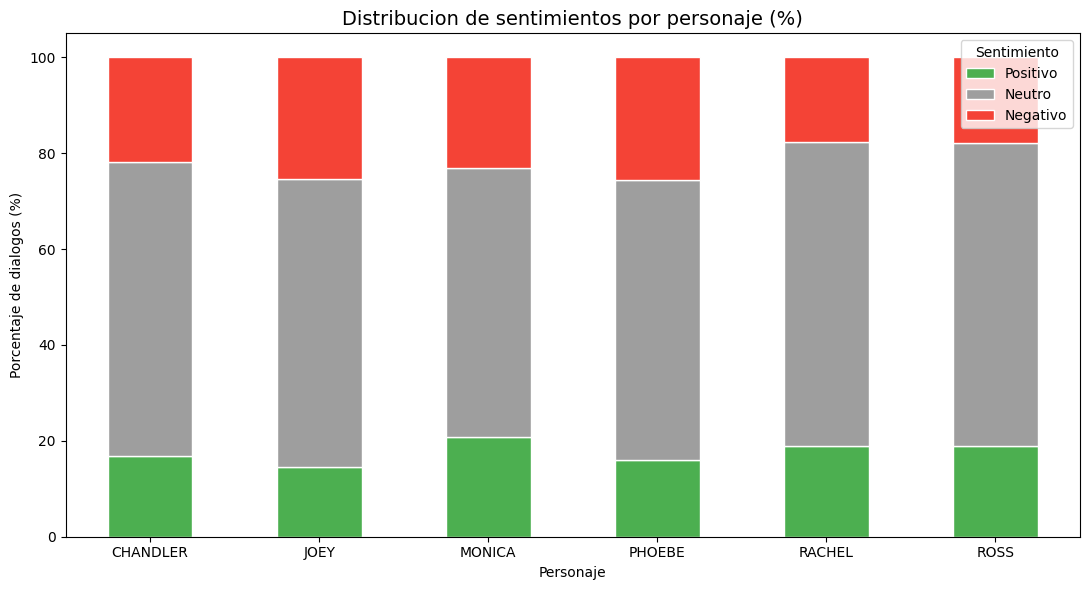

In [ ]:
# Grafico de barras apiladas por personaje
colores = {'POS': '#4CAF50', 'NEU': '#9E9E9E', 'NEG': '#F44336'}

fig, ax = plt.subplots(figsize=(11, 6))

conteo_porcentaje.plot(
    kind='bar',
    stacked=True,
    color=[colores['POS'], colores['NEU'], colores['NEG']],
    ax=ax,
    edgecolor='white'
)

ax.set_title('Distribucion de sentimientos por personaje (%)', fontsize=14)
ax.set_xlabel('Personaje')
ax.set_ylabel('Porcentaje de dialogos (%)')
ax.set_ylim(0, 105)
ax.legend(title='Sentimiento', labels=['Positivo', 'Neutro', 'Negativo'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

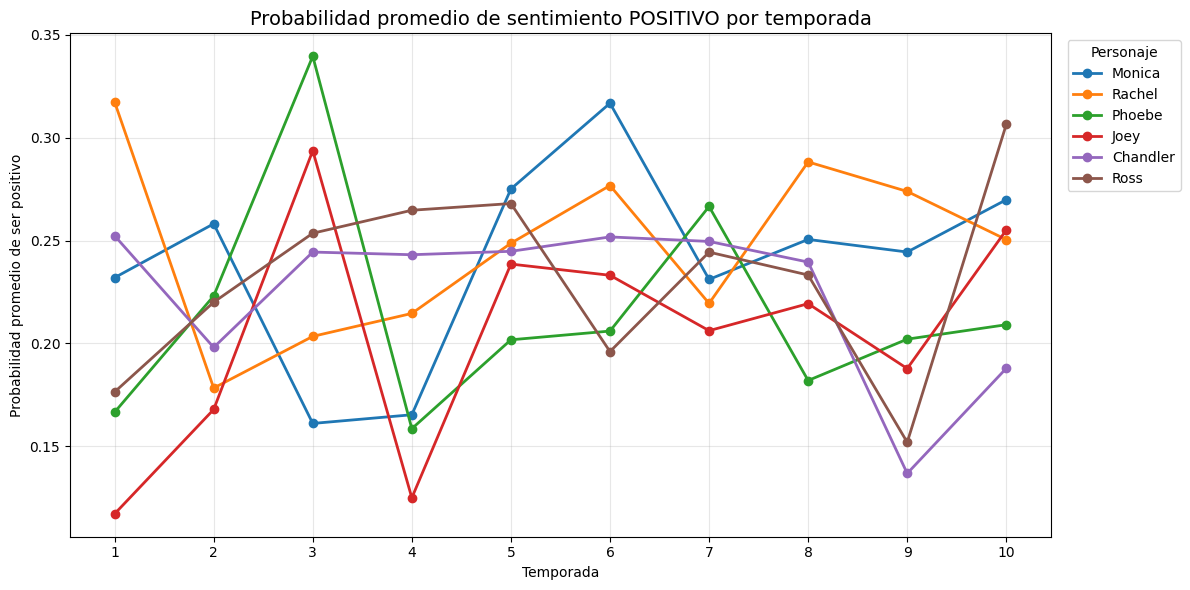

In [ ]:
# Promedio de probabilidad de sentimiento positivo por episodio y personaje
pivot_pos = (
    df_sentimientos
    .groupby(['temporada', 'personaje'])['prob_pos']
    .mean()
    .unstack()
    .reindex(columns=personaje_filtro)
)

plt.figure(figsize=(12, 6))

for personaje in personaje_filtro:
    if personaje in pivot_pos.columns:
        plt.plot(
            pivot_pos.index,
            pivot_pos[personaje],
            marker='o',
            label=personaje.capitalize(),
            linewidth=2
        )

plt.title('Probabilidad promedio de sentimiento POSITIVO por temporada', fontsize=14)
plt.xlabel('Temporada')
plt.ylabel('Probabilidad promedio de ser positivo')
plt.xticks(range(1, 11))
plt.legend(title='Personaje', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sentimientos_lineas.png', dpi=150)
plt.show()

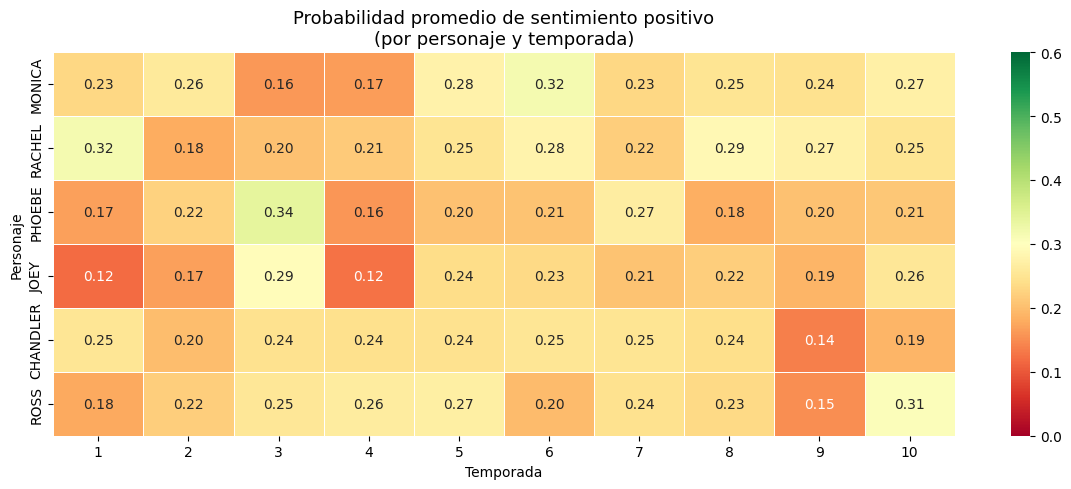

In [ ]:
# Heatmap de probabilidad positiva (personaje x temporada)
plt.figure(figsize=(12, 5))

sns.heatmap(
    pivot_pos.T,         # filas = personajes, columnas = temporadas
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',       # rojo = negativo, verde = positivo
    vmin=0, vmax=0.6,
    linewidths=0.5
)

plt.title('Probabilidad promedio de sentimiento positivo\n(por personaje y temporada)', fontsize=13)
plt.xlabel('Temporada')
plt.ylabel('Personaje')
plt.tight_layout()
plt.savefig('sentimientos_heatmap.png', dpi=150)
plt.show()

In [ ]:
# personaje mas positivo y mas negativo en promedio
promedio_por_personaje = (
    df_sentimientos
    .groupby('personaje')[['prob_pos', 'prob_neg', 'prob_neu']]
    .mean()
    .round(3)
)

print("Promedio de probabilidades de sentimiento por personaje:")
print(promedio_por_personaje)

personaje_mas_positivo = promedio_por_personaje['prob_pos'].idxmax()
personaje_mas_negativo = promedio_por_personaje['prob_neg'].idxmax()

print(f"\nPersonaje con dialogos MAS POSITIVOS en promedio: {personaje_mas_positivo}")
print(f"Personaje con dialogos MAS NEGATIVOS en promedio: {personaje_mas_negativo}")

Promedio de probabilidades de sentimiento por personaje:
           prob_pos  prob_neg  prob_neu
personaje                              
CHANDLER      0.228     0.266     0.506
JOEY          0.210     0.307     0.483
MONICA        0.245     0.288     0.467
PHOEBE        0.211     0.294     0.495
RACHEL        0.247     0.256     0.497
ROSS          0.235     0.251     0.514

Personaje con dialogos MAS POSITIVOS en promedio: RACHEL
Personaje con dialogos MAS NEGATIVOS en promedio: JOEY


##Robertaa

In [ ]:
from transformers import pipeline

In [ ]:
analizador_roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
analizador_roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def analizar_sentimiento_roberta(texto):
    try:
        resultado = analizador_roberta(texto)[0]

        etiqueta = resultado["label"]
        score = resultado["score"]

        # normalizamos nombres como tu pipeline anterior
        if etiqueta.lower().startswith("pos"):
            sentimiento = "POS"
        elif etiqueta.lower().startswith("neg"):
            sentimiento = "NEG"
        else:
            sentimiento = "NEU"

        return {
            "sentimiento_r": sentimiento,
            "prob_pos_r": score if sentimiento == "POS" else 0,
            "prob_neg_r": score if sentimiento == "NEG" else 0,
            "prob_neu_r": score if sentimiento == "NEU" else 0
        }

    except Exception:
        return {
            "sentimiento_r": "NEU",
            "prob_pos_r": 0,
            "prob_neg_r": 0,
            "prob_neu_r": 1
        }

In [ ]:

# Aplicamos el analisis a cada dialogo del DataFrame de personajes principales

resultados_sentimiento_roberta = df_principales['dialogo_original'].apply(analizar_sentimiento_roberta)


In [ ]:

# Expandimos el diccionario resultado en columnas del DataFrame
df_sentimientos_plus_roberta = pd.concat(
    [df_sentimientos.reset_index(drop=True),
     pd.DataFrame(list(resultados_sentimiento_roberta))],
    axis=1
)

print(f"Total de dialogos analizados: {len(df_sentimientos_plus_roberta)}")
df_sentimientos_plus_roberta[['personaje', 'dialogo_original', 'sentimiento', 'prob_pos', 'prob_neg', 'prob_neu']].head()

Total de dialogos analizados: 2341


,personaje,dialogo_original,sentimiento,prob_pos,prob_neg,prob_neu
0,MONICA,No hay nada que contar! Solo es un compañero más!,POS,0.672805,0.015249,0.311946
1,JOEY,Confiésalo... vas a salir con ese tío! Algo ra...,NEG,0.010358,0.876378,0.113265
2,CHANDLER,"Qué pasa, tiene joroba? Joroba y bisoñe?",NEU,0.019427,0.177721,0.802852
3,PHOEBE,"Espera, suele mascar tiza?",NEU,0.049477,0.225904,0.724619
4,PHOEBE,No me gustaría que pasase por lo que pase yo c...,NEG,0.014703,0.837856,0.147441


In [ ]:
# Contamos cuantos dialogos positivos, negativos y neutros tiene cada personaje
conteo_sentimientos_r = (
    df_sentimientos_plus_roberta
    .groupby(['personaje', 'sentimiento_r'])
    .size()
    .unstack(fill_value=0)  # cada sentimiento se vuelve columna
    .reindex(columns=['POS', 'NEU', 'NEG'], fill_value=0)  # orden fijo
)

# Calculamos el porcentaje de cada sentimiento por personaje
conteo_porcentaje_r = conteo_sentimientos_r.div(conteo_sentimientos_r.sum(axis=1), axis=0) * 100

print("Conteo de sentimientos por personaje:")
print(conteo_sentimientos_r)
print("\nPorcentaje de cada sentimiento por personaje:")
print(conteo_porcentaje_r.round(1))

Conteo de sentimientos por personaje:
sentimiento_r  POS  NEU  NEG
personaje                   
CHANDLER        67  190  100
JOEY            51  182   98
MONICA          74  216  110
PHOEBE          63  160   85
RACHEL          94  271  108
ROSS            91  278  103

Porcentaje de cada sentimiento por personaje:
sentimiento_r   POS   NEU   NEG
personaje                      
CHANDLER       18.8  53.2  28.0
JOEY           15.4  55.0  29.6
MONICA         18.5  54.0  27.5
PHOEBE         20.5  51.9  27.6
RACHEL         19.9  57.3  22.8
ROSS           19.3  58.9  21.8
